In [14]:
!pip install -q torch torchvision scikit-learn matplotlib seaborn numpy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [15]:
!curl -L https://download.pytorch.org/models/vit_b_16-c867db91.pth -o /Users/aakash/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  330M  100  330M    0     0  28.6M      0  0:00:11  0:00:11 --:--:-- 35.9M


In [16]:
import ssl
import urllib.request
ssl._create_default_https_context = ssl._create_unverified_context

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, models, transforms
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import copy

print("="*50)
print("PHASE 0: INITIALIZING VISION TRANSFORMER (ViT)")
print("="*50)

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ViT STRICTLY requires 224x224 images to form 16x16 patches perfectly
vit_base_transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

vit_augment_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.AutoAugment(policy=transforms.AutoAugmentPolicy.IMAGENET),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load Dataset
data_dir = './101_ObjectCategories' 
if not os.path.exists(data_dir):
    data_dir = './data/101_ObjectCategories'

dataset_base = datasets.ImageFolder(root=data_dir, transform=vit_base_transform)
num_classes = len(dataset_base.classes)
print(f"Detected {num_classes} object categories.")

# ViT Model Loader
def get_vit_model(num_out_nodes):
    model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    in_features = model.heads.head.in_features
    model.heads = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, num_out_nodes)
    )
    return model.to(device)

PHASE 0: INITIALIZING VISION TRANSFORMER (ViT)
Using device: mps
Detected 102 object categories.



RUN 1: ViT NAIVE BASELINE
Run 1 - Epoch 1/15 | Loss: 3.3528
Run 1 - Epoch 2/15 | Loss: 1.8020
Run 1 - Epoch 3/15 | Loss: 1.1144
Run 1 - Epoch 4/15 | Loss: 0.7739
Run 1 - Epoch 5/15 | Loss: 0.5970
Run 1 - Epoch 6/15 | Loss: 0.4952
Run 1 - Epoch 7/15 | Loss: 0.4328
Run 1 - Epoch 8/15 | Loss: 0.3872
Run 1 - Epoch 9/15 | Loss: 0.3546
Run 1 - Epoch 10/15 | Loss: 0.3354
Run 1 - Epoch 11/15 | Loss: 0.3159
Run 1 - Epoch 12/15 | Loss: 0.3076
Run 1 - Epoch 13/15 | Loss: 0.3030
Run 1 - Epoch 14/15 | Loss: 0.2964
Run 1 - Epoch 15/15 | Loss: 0.2996
                   precision    recall  f1-score   support

BACKGROUND_Google     0.7778    0.6931    0.7330       101
            Faces     0.9462    0.9565    0.9514        92
       Faces_easy     0.9663    0.9663    0.9663        89
         Leopards     0.9412    1.0000    0.9697        48
       Motorbikes     1.0000    1.0000    1.0000       158
        accordion     1.0000    1.0000    1.0000        13
        airplanes     0.9878    1.0000    0

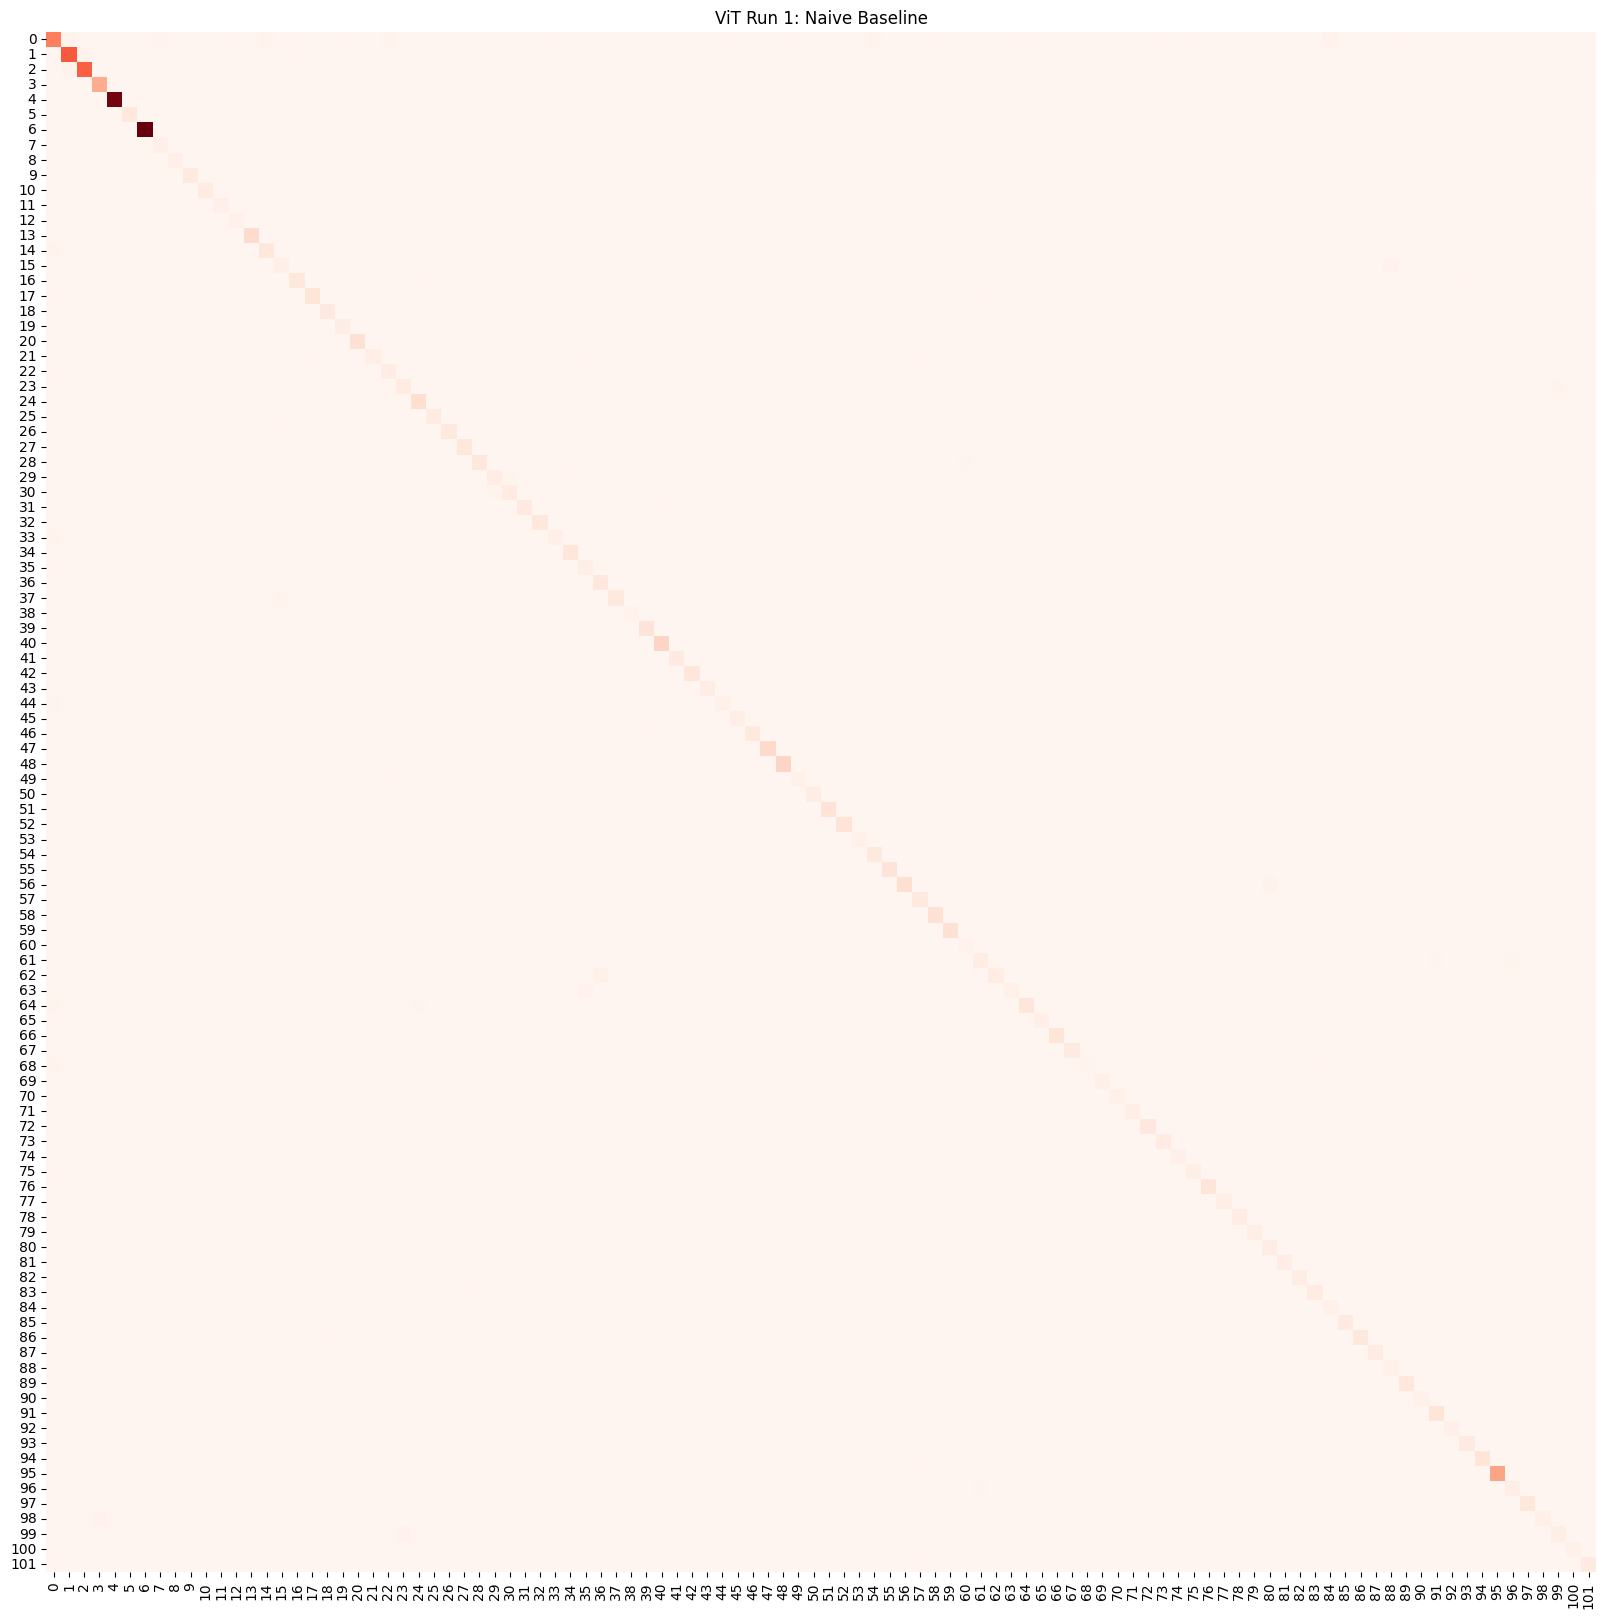

In [17]:
print("\n" + "="*50)
print("RUN 1: ViT NAIVE BASELINE")
print("="*50)

# 80/20 Random Split
train_size = int(0.8 * len(dataset_base))
val_size = len(dataset_base) - train_size
train_dataset_r1, val_dataset_r1 = random_split(dataset_base, [train_size, val_size])

train_loader_r1 = DataLoader(train_dataset_r1, batch_size=16, shuffle=True, num_workers=0)
val_loader_r1 = DataLoader(val_dataset_r1, batch_size=16, shuffle=False, num_workers=0)

model_vit_r1 = get_vit_model(num_classes)
criterion = nn.CrossEntropyLoss() 
optimizer_r1 = optim.AdamW(model_vit_r1.heads.parameters(), lr=1e-4)
scheduler_r1 = optim.lr_scheduler.CosineAnnealingLR(optimizer_r1, T_max=15)

num_epochs = 15
for epoch in range(num_epochs):
    model_vit_r1.train()
    running_loss = 0.0
    for inputs, labels in train_loader_r1:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_r1.zero_grad()
        outputs = model_vit_r1(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_r1.step()
        running_loss += loss.item() * inputs.size(0)
    scheduler_r1.step()
    print(f"Run 1 - Epoch {epoch+1}/{num_epochs} | Loss: {running_loss / len(train_dataset_r1):.4f}")

# Eval
model_vit_r1.eval()
y_true_r1, y_pred_r1 = [], []
with torch.no_grad():
    for inputs, labels in val_loader_r1:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_vit_r1(inputs)
        _, preds = torch.max(outputs, 1)
        y_true_r1.extend(labels.cpu().numpy())
        y_pred_r1.extend(preds.cpu().numpy())

print(classification_report(y_true_r1, y_pred_r1, digits=4, target_names=dataset_base.classes))
cm_r1 = confusion_matrix(y_true_r1, y_pred_r1)
plt.figure(figsize=(20, 20))
sns.heatmap(cm_r1, cmap='Reds', cbar=False) # Changed to Reds so you can tell ViT apart from EffNet!
plt.title('ViT Run 1: Naive Baseline')
plt.savefig('vit_run1_cm.png')


RUN 2: ViT STRATIFIED SPLIT
Run 2 - Epoch 1/15 | Loss: 3.3622
Run 2 - Epoch 2/15 | Loss: 1.8124
Run 2 - Epoch 3/15 | Loss: 1.1193
Run 2 - Epoch 4/15 | Loss: 0.7768
Run 2 - Epoch 5/15 | Loss: 0.6009
Run 2 - Epoch 6/15 | Loss: 0.4973
Run 2 - Epoch 7/15 | Loss: 0.4286
Run 2 - Epoch 8/15 | Loss: 0.3885
Run 2 - Epoch 9/15 | Loss: 0.3543
Run 2 - Epoch 10/15 | Loss: 0.3351
Run 2 - Epoch 11/15 | Loss: 0.3190
Run 2 - Epoch 12/15 | Loss: 0.3027
Run 2 - Epoch 13/15 | Loss: 0.2968
Run 2 - Epoch 14/15 | Loss: 0.2957
Run 2 - Epoch 15/15 | Loss: 0.2950
                   precision    recall  f1-score   support

BACKGROUND_Google     0.6790    0.5914    0.6322        93
            Faces     0.9540    0.9540    0.9540        87
       Faces_easy     0.9545    0.9655    0.9600        87
         Leopards     0.9756    1.0000    0.9877        40
       Motorbikes     1.0000    1.0000    1.0000       160
        accordion     1.0000    1.0000    1.0000        11
        airplanes     0.9877    1.0000   

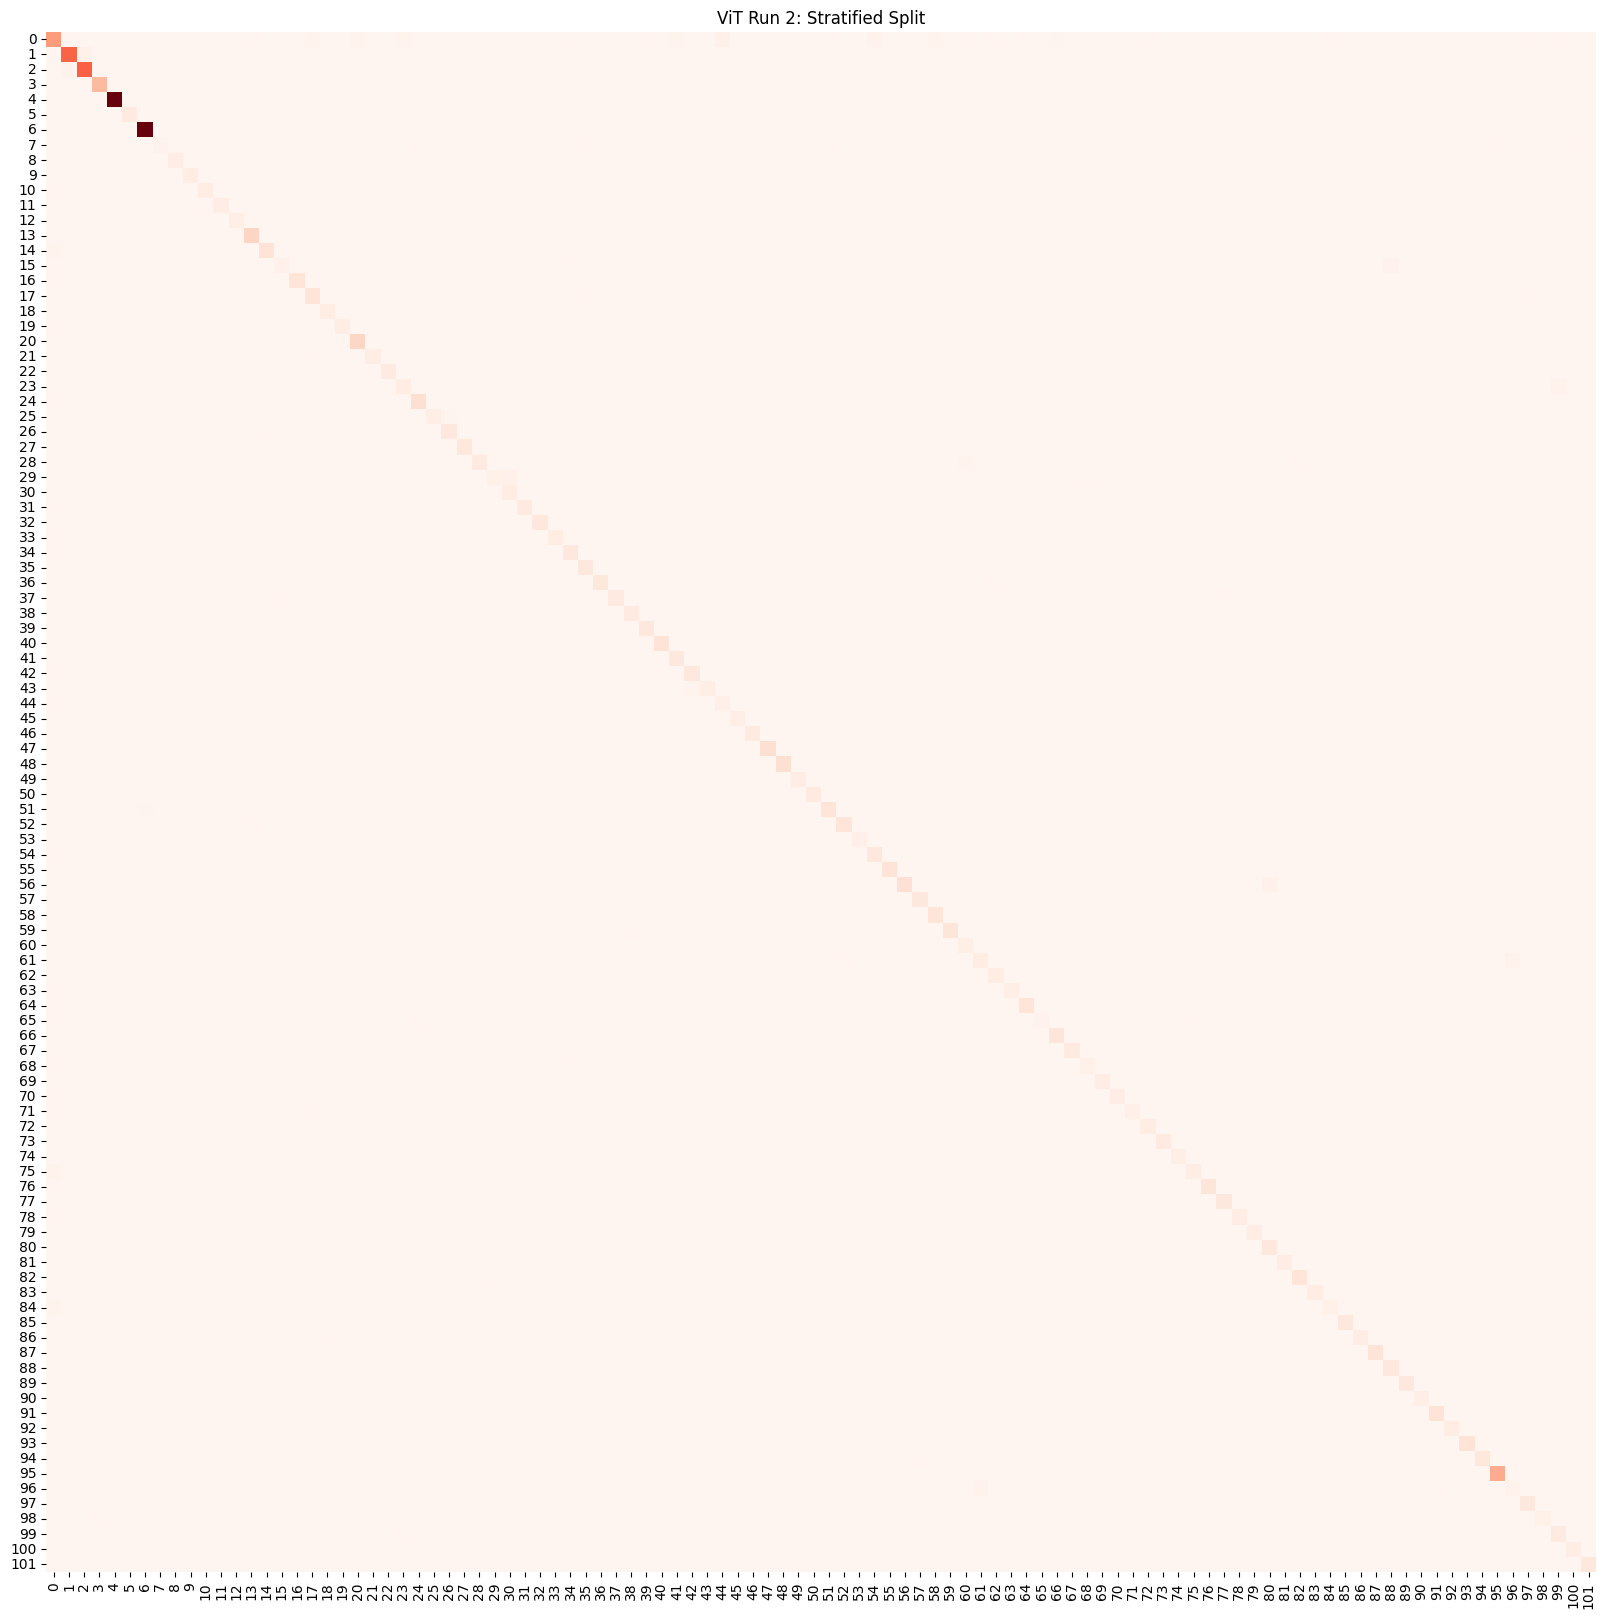

In [18]:
print("\n" + "="*50)
print("RUN 2: ViT STRATIFIED SPLIT")
print("="*50)

targets = dataset_base.targets 
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, val_idx in splitter.split(np.zeros(len(targets)), targets):
    train_indices = train_idx
    val_indices = val_idx

train_dataset_r2 = Subset(dataset_base, train_indices)
val_dataset_r2 = Subset(dataset_base, val_indices)

train_loader_r2 = DataLoader(train_dataset_r2, batch_size=16, shuffle=True, num_workers=0)
val_loader_r2 = DataLoader(val_dataset_r2, batch_size=16, shuffle=False, num_workers=0)

model_vit_r2 = get_vit_model(num_classes)
optimizer_r2 = optim.AdamW(model_vit_r2.heads.parameters(), lr=1e-4)
scheduler_r2 = optim.lr_scheduler.CosineAnnealingLR(optimizer_r2, T_max=15)

for epoch in range(num_epochs):
    model_vit_r2.train()
    running_loss = 0.0
    for inputs, labels in train_loader_r2:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_r2.zero_grad()
        outputs = model_vit_r2(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_r2.step()
        running_loss += loss.item() * inputs.size(0)
    scheduler_r2.step()
    print(f"Run 2 - Epoch {epoch+1}/{num_epochs} | Loss: {running_loss / len(train_dataset_r2):.4f}")

# Eval
model_vit_r2.eval()
y_true_r2, y_pred_r2 = [], []
with torch.no_grad():
    for inputs, labels in val_loader_r2:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_vit_r2(inputs)
        _, preds = torch.max(outputs, 1)
        y_true_r2.extend(labels.cpu().numpy())
        y_pred_r2.extend(preds.cpu().numpy())

print(classification_report(y_true_r2, y_pred_r2, digits=4, target_names=dataset_base.classes))
cm_r2 = confusion_matrix(y_true_r2, y_pred_r2)
plt.figure(figsize=(20, 20))
sns.heatmap(cm_r2, cmap='Reds', cbar=False)
plt.title('ViT Run 2: Stratified Split')
plt.savefig('vit_run2_cm.png')


RUN 3: ViT AUTOAUGMENT
Run 3 - Epoch 1/15 | Loss: 3.5535
Run 3 - Epoch 2/15 | Loss: 2.0621
Run 3 - Epoch 3/15 | Loss: 1.3784
Run 3 - Epoch 4/15 | Loss: 1.0007
Run 3 - Epoch 5/15 | Loss: 0.8111
Run 3 - Epoch 6/15 | Loss: 0.6969
Run 3 - Epoch 7/15 | Loss: 0.6165
Run 3 - Epoch 8/15 | Loss: 0.5591
Run 3 - Epoch 9/15 | Loss: 0.5180
Run 3 - Epoch 10/15 | Loss: 0.4926
Run 3 - Epoch 11/15 | Loss: 0.4711
Run 3 - Epoch 12/15 | Loss: 0.4679
Run 3 - Epoch 13/15 | Loss: 0.4524
Run 3 - Epoch 14/15 | Loss: 0.4615
Run 3 - Epoch 15/15 | Loss: 0.4448
                   precision    recall  f1-score   support

BACKGROUND_Google     0.6709    0.5699    0.6163        93
            Faces     0.9425    0.9425    0.9425        87
       Faces_easy     0.9438    0.9655    0.9545        87
         Leopards     0.9524    1.0000    0.9756        40
       Motorbikes     0.9938    1.0000    0.9969       160
        accordion     1.0000    1.0000    1.0000        11
        airplanes     0.9876    0.9938    0.99

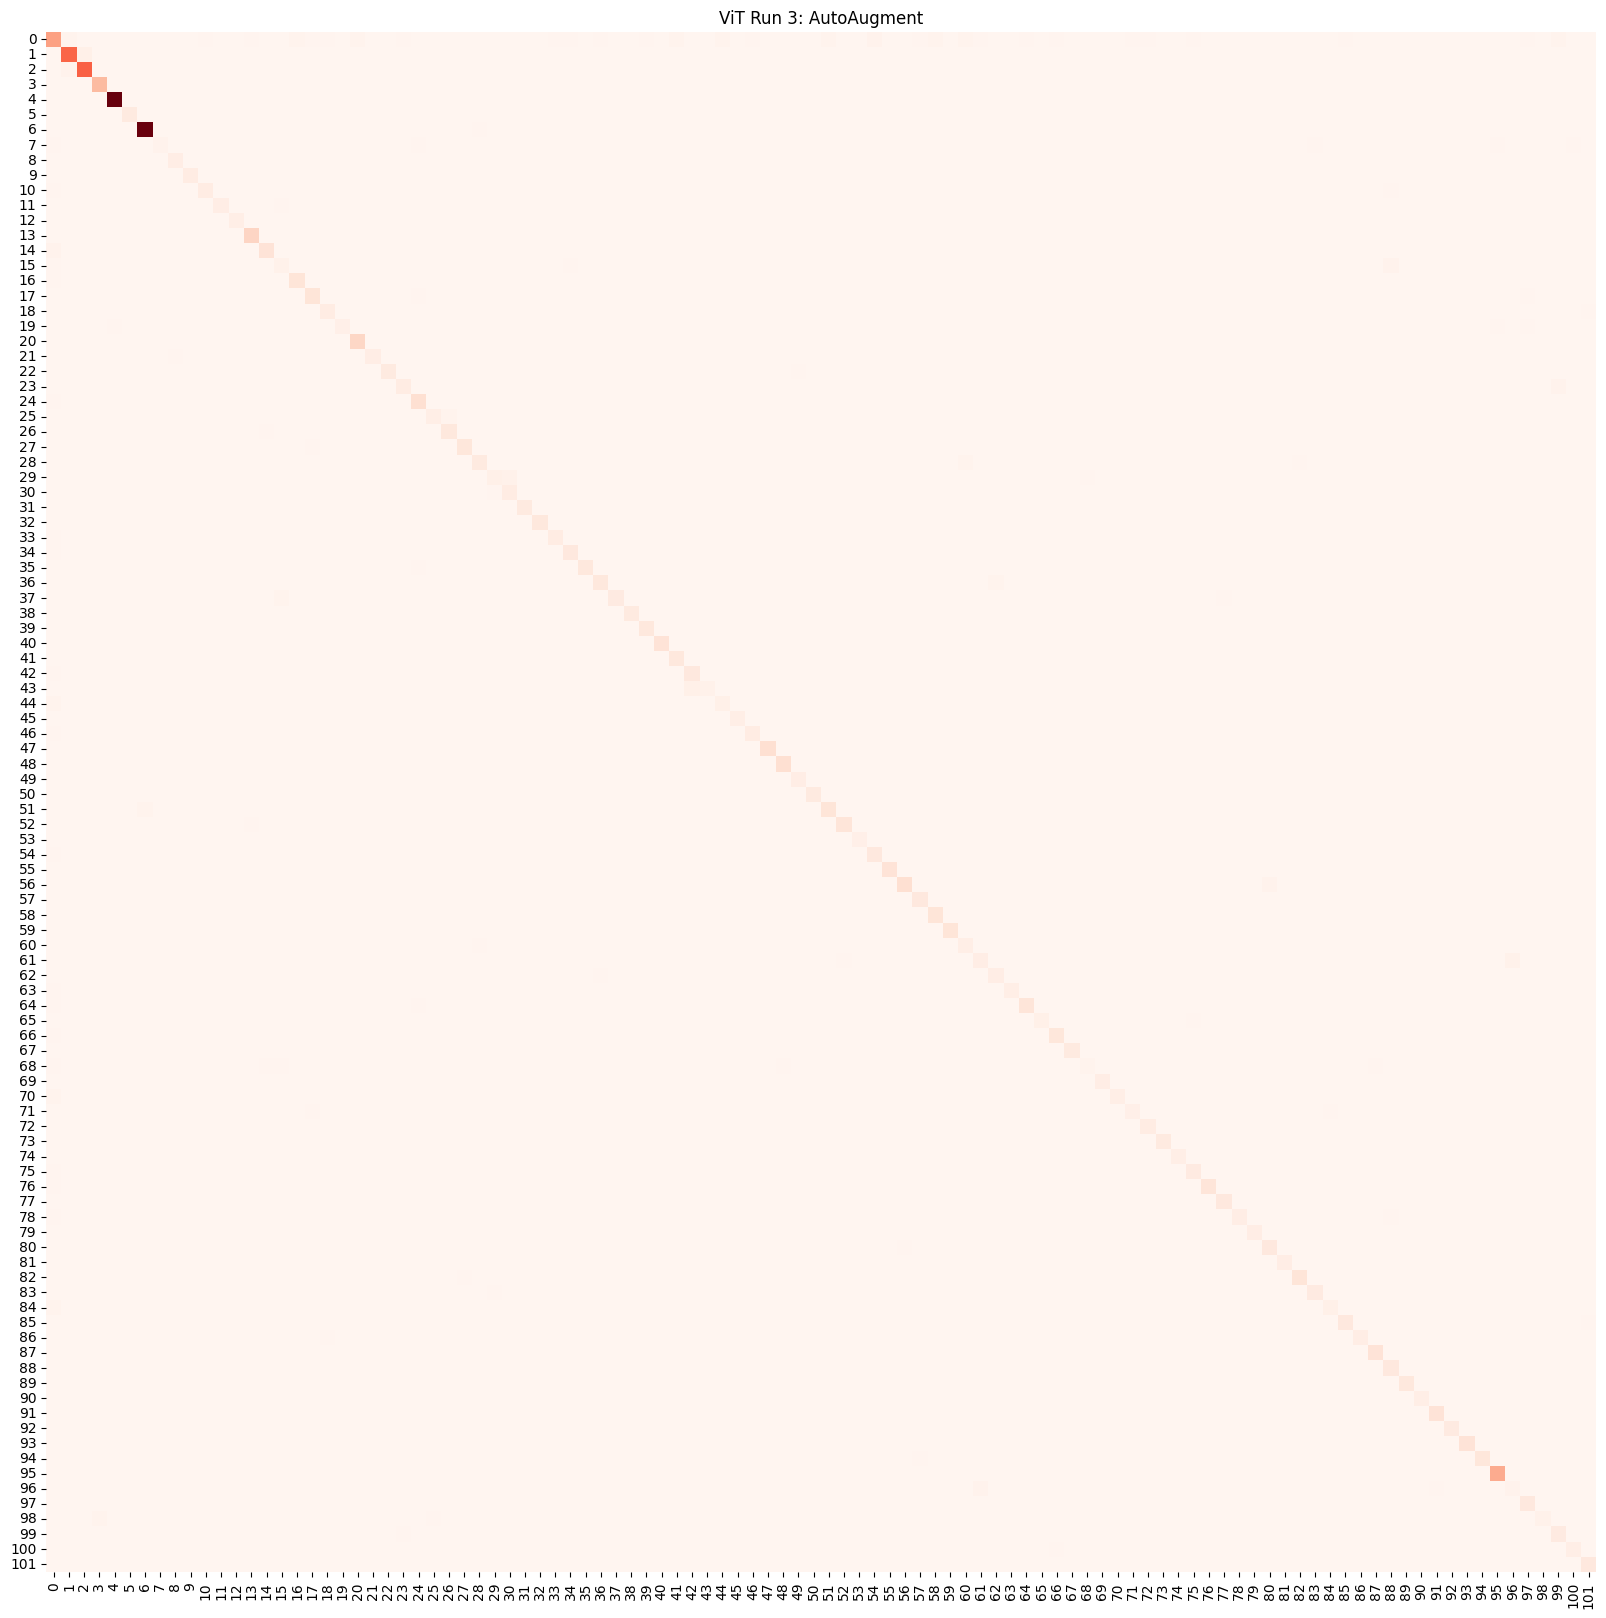

In [19]:
print("\n" + "="*50)
print("RUN 3: ViT AUTOAUGMENT")
print("="*50)

dataset_aug = datasets.ImageFolder(root=data_dir, transform=vit_augment_transform)
train_dataset_r3 = Subset(dataset_aug, train_indices) # Reuse exact strat indices

train_loader_r3 = DataLoader(train_dataset_r3, batch_size=16, shuffle=True, num_workers=0)

model_vit_r3 = get_vit_model(num_classes)
optimizer_r3 = optim.AdamW(model_vit_r3.heads.parameters(), lr=1e-4)
scheduler_r3 = optim.lr_scheduler.CosineAnnealingLR(optimizer_r3, T_max=15)

for epoch in range(num_epochs):
    model_vit_r3.train()
    running_loss = 0.0
    for inputs, labels in train_loader_r3:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_r3.zero_grad()
        outputs = model_vit_r3(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_r3.step()
        running_loss += loss.item() * inputs.size(0)
    scheduler_r3.step()
    print(f"Run 3 - Epoch {epoch+1}/{num_epochs} | Loss: {running_loss / len(train_dataset_r3):.4f}")

# Eval
model_vit_r3.eval()
y_true_r3, y_pred_r3 = [], []
with torch.no_grad():
    for inputs, labels in val_loader_r2:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_vit_r3(inputs)
        _, preds = torch.max(outputs, 1)
        y_true_r3.extend(labels.cpu().numpy())
        y_pred_r3.extend(preds.cpu().numpy())

print(classification_report(y_true_r3, y_pred_r3, digits=4, target_names=dataset_base.classes))
cm_r3 = confusion_matrix(y_true_r3, y_pred_r3)
plt.figure(figsize=(20, 20))
sns.heatmap(cm_r3, cmap='Reds', cbar=False)
plt.title('ViT Run 3: AutoAugment')
plt.savefig('vit_run3_cm.png')


RUN 4: ViT WEIGHTED LOSS (SOTA)
Run 4 - Epoch 1/15 | Loss: 3.9796
Run 4 - Epoch 2/15 | Loss: 2.6599
Run 4 - Epoch 3/15 | Loss: 1.8121
Run 4 - Epoch 4/15 | Loss: 1.3005
Run 4 - Epoch 5/15 | Loss: 1.0283
Run 4 - Epoch 6/15 | Loss: 0.8353
Run 4 - Epoch 7/15 | Loss: 0.7384
Run 4 - Epoch 8/15 | Loss: 0.6718
Run 4 - Epoch 9/15 | Loss: 0.6127
Run 4 - Epoch 10/15 | Loss: 0.5709
Run 4 - Epoch 11/15 | Loss: 0.5539
Run 4 - Epoch 12/15 | Loss: 0.5417
Run 4 - Epoch 13/15 | Loss: 0.5455
Run 4 - Epoch 14/15 | Loss: 0.5183
Run 4 - Epoch 15/15 | Loss: 0.5264
                   precision    recall  f1-score   support

BACKGROUND_Google     1.0000    0.4301    0.6015        93
            Faces     0.9634    0.9080    0.9349        87
       Faces_easy     0.9231    0.9655    0.9438        87
         Leopards     0.9756    1.0000    0.9877        40
       Motorbikes     1.0000    1.0000    1.0000       160
        accordion     1.0000    1.0000    1.0000        11
        airplanes     0.9876    0.993

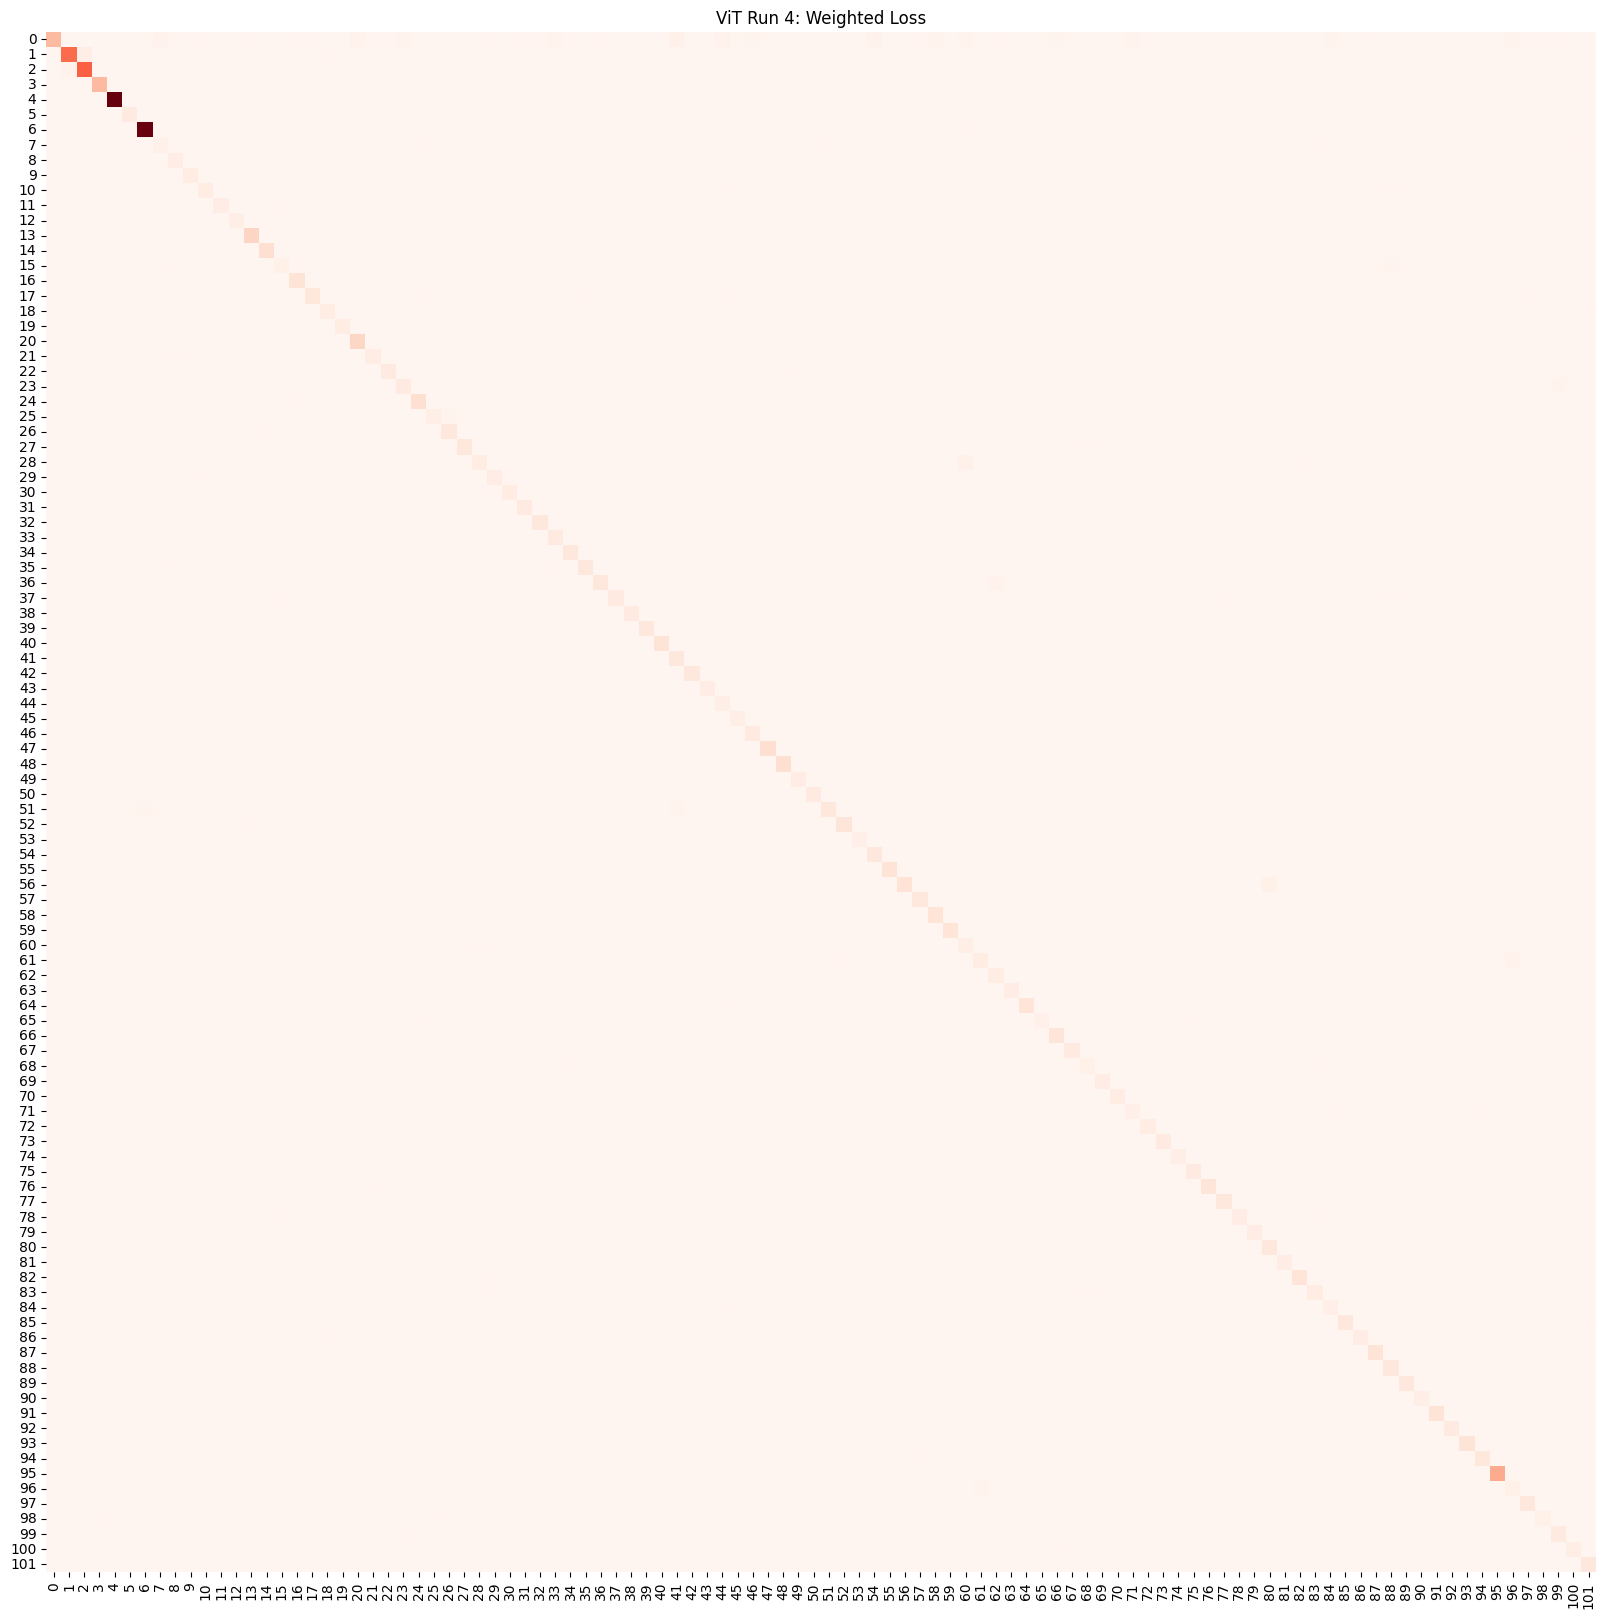

In [20]:
print("\n" + "="*50)
print("RUN 4: ViT WEIGHTED LOSS (SOTA)")
print("="*50)

train_labels = [dataset_aug.targets[i] for i in train_indices]
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

model_vit_r4 = get_vit_model(num_classes)
criterion_weighted = nn.CrossEntropyLoss(weight=weights_tensor) 
optimizer_r4 = optim.AdamW(model_vit_r4.heads.parameters(), lr=1e-4)
scheduler_r4 = optim.lr_scheduler.CosineAnnealingLR(optimizer_r4, T_max=15)

for epoch in range(num_epochs):
    model_vit_r4.train()
    running_loss = 0.0
    for inputs, labels in train_loader_r3:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_r4.zero_grad()
        outputs = model_vit_r4(inputs)
        loss = criterion_weighted(outputs, labels)
        loss.backward()
        optimizer_r4.step()
        running_loss += loss.item() * inputs.size(0)
    scheduler_r4.step()
    print(f"Run 4 - Epoch {epoch+1}/{num_epochs} | Loss: {running_loss / len(train_dataset_r3):.4f}")

# Eval
model_vit_r4.eval()
y_true_r4, y_pred_r4 = [], []
with torch.no_grad():
    for inputs, labels in val_loader_r2:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_vit_r4(inputs)
        _, preds = torch.max(outputs, 1)
        y_true_r4.extend(labels.cpu().numpy())
        y_pred_r4.extend(preds.cpu().numpy())

print(classification_report(y_true_r4, y_pred_r4, digits=4, target_names=dataset_base.classes))
cm_r4 = confusion_matrix(y_true_r4, y_pred_r4)
plt.figure(figsize=(20, 20))
sns.heatmap(cm_r4, cmap='Reds', cbar=False)
plt.title('ViT Run 4: Weighted Loss')
plt.savefig('vit_run4_cm.png')

In [21]:
print("\n" + "="*50)
print("SAVING ViT MODELS TO DISK")
print("="*50)

torch.save(model_vit_r1.state_dict(), 'vit_run1_naive.pth')
print("✅ ViT Run 1 saved as: vit_run1_naive.pth")

torch.save(model_vit_r2.state_dict(), 'vit_run2_stratified.pth')
print("✅ ViT Run 2 saved as: vit_run2_stratified.pth")

torch.save(model_vit_r3.state_dict(), 'vit_run3_augment.pth')
print("✅ ViT Run 3 saved as: vit_run3_augment.pth")

torch.save(model_vit_r4.state_dict(), 'vit_run4_sota.pth')
print("✅ ViT Run 4 saved as: vit_run4_sota.pth")



SAVING ViT MODELS TO DISK
✅ ViT Run 1 saved as: vit_run1_naive.pth
✅ ViT Run 2 saved as: vit_run2_stratified.pth
✅ ViT Run 3 saved as: vit_run3_augment.pth
✅ ViT Run 4 saved as: vit_run4_sota.pth

Night shift complete! All data secured.


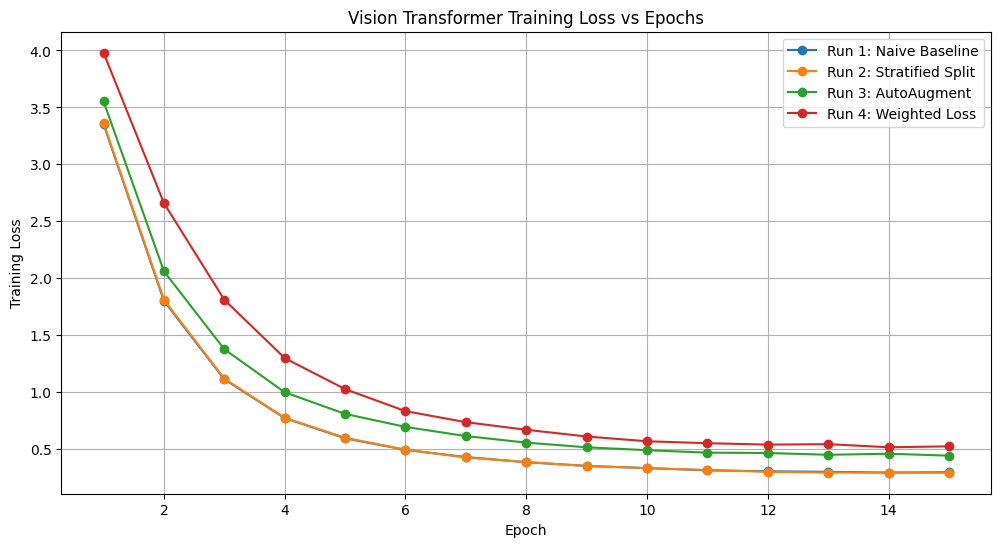

Saved as vit_training_loss.png


In [5]:
import matplotlib.pyplot as plt

# Vision Transformer (ViT) Training Loss Graph (Hardcoded, using values provided by training)

epochs = list(range(1, 16))

run1 = [3.3528, 1.8020, 1.1144, 0.7739, 0.5970,
        0.4952, 0.4328, 0.3872, 0.3546, 0.3354,
        0.3159, 0.3076, 0.3030, 0.2964, 0.2996]

run2 = [3.3622, 1.8124, 1.1193, 0.7768, 0.6009,
        0.4973, 0.4286, 0.3885, 0.3543, 0.3351,
        0.3190, 0.3027, 0.2968, 0.2957, 0.2950]

run3 = [3.5535, 2.0621, 1.3784, 1.0007, 0.8111,
        0.6969, 0.6165, 0.5591, 0.5180, 0.4926,
        0.4711, 0.4679, 0.4524, 0.4615, 0.4448]

run4 = [3.9796, 2.6599, 1.8121, 1.3005, 1.0283,
        0.8353, 0.7384, 0.6718, 0.6127, 0.5709,
        0.5539, 0.5417, 0.5455, 0.5183, 0.5264]

plt.figure(figsize=(12, 6))

plt.plot(epochs, run1, marker='o', label='Run 1: Naive Baseline')
plt.plot(epochs, run2, marker='o', label='Run 2: Stratified Split')
plt.plot(epochs, run3, marker='o', label='Run 3: AutoAugment')
plt.plot(epochs, run4, marker='o', label='Run 4: Weighted Loss')

plt.title("Vision Transformer Training Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.grid(True)

plt.savefig("vit_training_loss.png", dpi=300, bbox_inches='tight')

plt.show()

print("Saved as vit_training_loss.png")